
# Item (c) — Viga Cantilever com elementos de Hermite

In [18]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## Parâmetros do problema

In [ ]:

comprimento = 3.0
rigidez_flexao = 1.8e3
carga_distribuida = 100.0
n_elementos = 10


## Funções de forma cúbicas de Hermite

No elemento de referência $\xi\in[0,1]$, usamos

$$
N_1(\xi)=1-3\xi^2+2\xi^3,
$$

$$
N_2(\xi)=h(\xi-2\xi^2+\xi^3),
$$

$$
N_3(\xi)=3\xi^2-2\xi^3,
$$

$$
N_4(\xi)=h(-\xi^2+\xi^3).
$$

Os graus de liberdade locais são

$$
[u_i,\theta_i,u_{i+1},\theta_{i+1}],
$$

onde $\theta_i=u'(x_i)$.


In [20]:

def funcoes_hermite(xi: np.ndarray, h: float) -> np.ndarray:
    xi = np.asarray(xi)
    n1 = 1.0 - 3.0 * xi**2 + 2.0 * xi**3
    n2 = h * (xi - 2.0 * xi**2 + xi**3)
    n3 = 3.0 * xi**2 - 2.0 * xi**3
    n4 = h * (-xi**2 + xi**3)
    return np.vstack([n1, n2, n3, n4])


def segundas_derivadas_hermite(xi: np.ndarray, h: float) -> np.ndarray:
    xi = np.asarray(xi)

    # d2N/dxi2
    d2n1_dxi2 = -6.0 + 12.0 * xi
    d2n2_dxi2 = h * (-4.0 + 6.0 * xi)
    d2n3_dxi2 = 6.0 - 12.0 * xi
    d2n4_dxi2 = h * (-2.0 + 6.0 * xi)

    # Como x = x_i + h xi, então d2/dx2 = (1/h2)d2/dxi2
    return np.vstack([d2n1_dxi2, d2n2_dxi2, d2n3_dxi2, d2n4_dxi2]) / h**2



## Matrizes locais

A matriz de rigidez local é

$$
K_e = EI\int_{K_e} B^T B\,dx,
$$

onde $B$ contém as segundas derivadas das funções de forma. O vetor de força local é

$$
F_e=\int_{K_e} f N^T\,dx.
$$


In [21]:

def montar_matriz_local(h: float, rigidez_flexao: float) -> np.ndarray:
    fator = rigidez_flexao / h**3
    return fator * np.array([
        [12.0, 6.0*h, -12.0, 6.0*h],
        [6.0*h, 4.0*h**2, -6.0*h, 2.0*h**2],
        [-12.0, -6.0*h, 12.0, -6.0*h],
        [6.0*h, 2.0*h**2, -6.0*h, 4.0*h**2],
    ])


def montar_forca_local(h: float, carga: float) -> np.ndarray:
    return carga * np.array([
        h / 2.0,
        h**2 / 12.0,
        h / 2.0,
        -h**2 / 12.0,
    ])



## Montagem global e condições de contorno


In [ ]:

def resolver_viga_cantilever(
    comprimento: float,
    rigidez_flexao: float,
    carga_distribuida: float,
    n_elementos: int,
) -> tuple[np.ndarray, np.ndarray]:
    n_nos = n_elementos + 1
    n_graus_liberdade = 2 * n_nos
    h = comprimento / n_elementos

    matriz_global = np.zeros((n_graus_liberdade, n_graus_liberdade))
    vetor_global = np.zeros(n_graus_liberdade)

    matriz_local = montar_matriz_local(h, rigidez_flexao)
    forca_local = montar_forca_local(h, carga_distribuida)

    for elemento in range(n_elementos):
        dofs = np.array([
            2 * elemento,
            2 * elemento + 1,
            2 * (elemento + 1),
            2 * (elemento + 1) + 1,
        ])

        matriz_global[np.ix_(dofs, dofs)] += matriz_local
        vetor_global[dofs] += forca_local

    # Condições: u(0)=0 e u'(0)=0
    graus_fixos = np.array([0, 1])
    graus_livres = np.setdiff1d(np.arange(n_graus_liberdade), graus_fixos)

    matriz_reduzida = matriz_global[np.ix_(graus_livres, graus_livres)]
    vetor_reduzido = vetor_global[graus_livres]

    solucao = np.zeros(n_graus_liberdade)
    solucao[graus_livres] = np.linalg.solve(matriz_reduzida, vetor_reduzido)

    nos = np.linspace(0.0, comprimento, n_nos)
    return nos, solucao


## Solução analítica e avaliação da solução numérica

In [ ]:

def solucao_analitica(x: np.ndarray, comprimento: float, rigidez_flexao: float, carga: float) -> np.ndarray:
    return carga * x**2 * (6.0 * comprimento**2 - 4.0 * comprimento * x + x**2) / (24.0 * rigidez_flexao)


def avaliar_solucao(nos: np.ndarray, solucao: np.ndarray, pontos_por_elemento: int = 30) -> tuple[np.ndarray, np.ndarray]:
    xs = []
    us = []

    for elemento in range(len(nos) - 1):
        x0 = nos[elemento]
        x1 = nos[elemento + 1]
        h = x1 - x0

        xi = np.linspace(0.0, 1.0, pontos_por_elemento, endpoint=False)
        if elemento == len(nos) - 2:
            xi = np.linspace(0.0, 1.0, pontos_por_elemento, endpoint=True)

        dofs = np.array([
            2 * elemento,
            2 * elemento + 1,
            2 * (elemento + 1),
            2 * (elemento + 1) + 1,
        ])
        coef_locais = solucao[dofs]
        N = funcoes_hermite(xi, h)
        u_local = coef_locais @ N
        x_local = x0 + h * xi

        xs.append(x_local)
        us.append(u_local)

    return np.concatenate(xs), np.concatenate(us)


In [ ]:

nos, solucao = resolver_viga_cantilever(
    comprimento=comprimento,
    rigidez_flexao=rigidez_flexao,
    carga_distribuida=carga_distribuida,
    n_elementos=n_elementos,
)

x_plot, u_h_plot = avaliar_solucao(nos, solucao)
u_exata_plot = solucao_analitica(x_plot, comprimento, rigidez_flexao, carga_distribuida)

valores_nos = solucao[0::2]
rotacoes_nos = solucao[1::2]

u_exata_ponta = solucao_analitica(np.array([comprimento]), comprimento, rigidez_flexao, carga_distribuida)[0]

print(f"Número de elementos: {n_elementos}")
print(f"Comprimento do elemento h: {comprimento / n_elementos:.6f}")
print(f"Deslocamento na ponta u_h(L): {valores_nos[-1]:.10f}")
print(f"Solução exata na ponta u(L): {u_exata_ponta:.10f}")
print(f"Erro absoluto na ponta: {abs(valores_nos[-1] - u_exata_ponta):.3e}")


Número de elementos: 10
Comprimento do elemento h: 0.300000
Deslocamento na ponta u_h(L): 0.5625000000
Solução exata na ponta u(L): 0.5625000000
Erro absoluto na ponta: 1.172e-13


## Gráfico comparando solução numérica e solução analítica

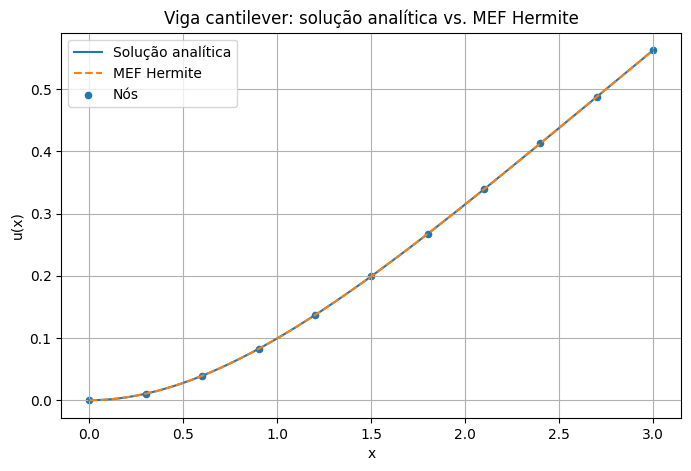

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(x_plot, u_exata_plot, label="Solução analítica")
plt.plot(x_plot, u_h_plot, "--", label="MEF Hermite")
plt.scatter(nos, valores_nos, s=20, label="Nós")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Viga cantilever: solução analítica vs. MEF Hermite")
plt.legend()
plt.grid(True)
plt.show()



## Erro na norma $L^2(0,L)$

Calculamos o erro por quadratura de Gauss em cada elemento:



In [ ]:

def erro_l2(
    comprimento: float,
    rigidez_flexao: float,
    carga_distribuida: float,
    n_elementos: int,
    ordem_quadratura: int = 5,
) -> float:
    nos, solucao = resolver_viga_cantilever(
        comprimento=comprimento,
        rigidez_flexao=rigidez_flexao,
        carga_distribuida=carga_distribuida,
        n_elementos=n_elementos,
    )

    pontos, pesos = np.polynomial.legendre.leggauss(ordem_quadratura)
    xis = 0.5 * (pontos + 1.0)
    pesos_ref = 0.5 * pesos

    erro_quad = 0.0

    for elemento in range(n_elementos):
        x0 = nos[elemento]
        x1 = nos[elemento + 1]
        h = x1 - x0
        xq = x0 + h * xis

        dofs = np.array([
            2 * elemento,
            2 * elemento + 1,
            2 * (elemento + 1),
            2 * (elemento + 1) + 1,
        ])
        coef_locais = solucao[dofs]
        N = funcoes_hermite(xis, h)
        uh_q = coef_locais @ N
        u_q = solucao_analitica(xq, comprimento, rigidez_flexao, carga_distribuida)

        erro_quad += h * np.sum(pesos_ref * (u_q - uh_q)**2)

    return np.sqrt(erro_quad)

print(f"Erro L2 com {n_elementos} elementos: {erro_l2(comprimento, rigidez_flexao, carga_distribuida, n_elementos):.3e}")


Erro L2 com 10 elementos: 1.294e-06



# Item (d) — Estudo de convergência $h$



## Derivadas necessárias para os erros

Para calcular as seminormas $H^1(\Omega)$ e $H^2(\Omega)$, precisamos comparar $u'$ com $u_h'$ e $u''$ com $u_h''$.

A solução analítica é

$$
u(x)=\frac{f x^2(6L^2-4Lx+x^2)}{24EI}.
$$

Logo,

$$
u'(x)=\frac{f}{24EI}(12L^2x-12Lx^2+4x^3),
$$

e

$$
u''(x)=\frac{f}{2EI}(L-x)^2.
$$


In [27]:

def derivada_solucao_analitica(
    x: np.ndarray,
    comprimento: float,
    rigidez_flexao: float,
    carga: float,
) -> np.ndarray:
    return carga * (
        12.0 * comprimento**2 * x
        - 12.0 * comprimento * x**2
        + 4.0 * x**3
    ) / (24.0 * rigidez_flexao)


def segunda_derivada_solucao_analitica(
    x: np.ndarray,
    comprimento: float,
    rigidez_flexao: float,
    carga: float,
) -> np.ndarray:
    return carga * (comprimento - x)**2 / (2.0 * rigidez_flexao)



## Derivadas primeiras das funções de Hermite
Para o erro em $H^1(\Omega)$, precisamos também de $dN_i/dx$.


In [33]:

def primeiras_derivadas_hermite(xi: np.ndarray, h: float) -> np.ndarray:
    xi = np.asarray(xi)

    dn1_dxi = -6.0 * xi + 6.0 * xi**2
    dn2_dxi = h * (1.0 - 4.0 * xi + 3.0 * xi**2)
    dn3_dxi = 6.0 * xi - 6.0 * xi**2
    dn4_dxi = h * (-2.0 * xi + 3.0 * xi**2)

    return np.vstack([dn1_dxi, dn2_dxi, dn3_dxi, dn4_dxi]) / h



## Cálculo dos erros em $L^2$, $H^1$ e $H^2$

Calculamos

$$
\|u-u_h\|_{L^2(\Omega)}
=
\left(
\int_0^L |u-u_h|^2\,dx
\right)^{1/2},
$$

$$
|u-u_h|_{H^1(\Omega)}
=
\left(
\int_0^L |u'-u_h'|^2\,dx
\right)^{1/2},
$$

$$
|u-u_h|_{H^2(\Omega)}
=
\left(
\int_0^L |u''-u_h''|^2\,dx
\right)^{1/2}
$$


In [ ]:

def calcular_erros_convergencia(
    comprimento: float,
    rigidez_flexao: float,
    carga_distribuida: float,
    n_elementos: int,
    ordem_quadratura: int = 6,
) -> tuple[float, float, float]:
    nos, solucao = resolver_viga_cantilever(
        comprimento=comprimento,
        rigidez_flexao=rigidez_flexao,
        carga_distribuida=carga_distribuida,
        n_elementos=n_elementos,
    )

    pontos, pesos = np.polynomial.legendre.leggauss(ordem_quadratura)
    xis = 0.5 * (pontos + 1.0)
    pesos_ref = 0.5 * pesos

    erro_l2_quadrado = 0.0
    erro_h1_quadrado = 0.0
    erro_h2_quadrado = 0.0

    for elemento in range(n_elementos):
        x0 = nos[elemento]
        x1 = nos[elemento + 1]
        h = x1 - x0
        xq = x0 + h * xis

        dofs = np.array([
            2 * elemento,
            2 * elemento + 1,
            2 * (elemento + 1),
            2 * (elemento + 1) + 1,
        ])

        coef_locais = solucao[dofs]

        N = funcoes_hermite(xis, h)
        dN = primeiras_derivadas_hermite(xis, h)
        d2N = segundas_derivadas_hermite(xis, h)

        uh_q = coef_locais @ N
        duh_q = coef_locais @ dN
        d2uh_q = coef_locais @ d2N

        u_q = solucao_analitica(
            xq,
            comprimento,
            rigidez_flexao,
            carga_distribuida,
        )
        du_q = derivada_solucao_analitica(
            xq,
            comprimento,
            rigidez_flexao,
            carga_distribuida,
        )
        d2u_q = segunda_derivada_solucao_analitica(
            xq,
            comprimento,
            rigidez_flexao,
            carga_distribuida,
        )

        erro_l2_quadrado += h * np.sum(pesos_ref * (u_q - uh_q)**2)
        erro_h1_quadrado += h * np.sum(pesos_ref * (du_q - duh_q)**2)
        erro_h2_quadrado += h * np.sum(pesos_ref * (d2u_q - d2uh_q)**2)

    return (
        np.sqrt(erro_l2_quadrado),
        np.sqrt(erro_h1_quadrado),
        np.sqrt(erro_h2_quadrado),
    )



## Experimento de convergência

Usamos malhas uniformes com

$$
h=\frac{L}{N},
$$

onde $N$ é o número de elementos.


In [ ]:

ns_elementos = np.array([2, 4, 8, 16, 32, 64])
resultados = []

for n_elementos in ns_elementos:
    erro_l2_atual, erro_h1_atual, erro_h2_atual = calcular_erros_convergencia(
        comprimento=comprimento,
        rigidez_flexao=rigidez_flexao,
        carga_distribuida=carga_distribuida,
        n_elementos=n_elementos,
    )

    h_atual = comprimento / n_elementos

    resultados.append({
        "elementos": n_elementos,
        "h": h_atual,
        "erro_L2": erro_l2_atual,
        "erro_H1": erro_h1_atual,
        "erro_H2": erro_h2_atual,
    })

tabela_convergencia = pd.DataFrame(resultados)

for coluna in ["erro_L2", "erro_H1", "erro_H2"]:
    tabela_convergencia[f"taxa_{coluna}"] = np.nan

    for i in range(1, len(tabela_convergencia)):
        erro_anterior = tabela_convergencia.loc[i - 1, coluna]
        erro_atual = tabela_convergencia.loc[i, coluna]

        h_anterior = tabela_convergencia.loc[i - 1, "h"]
        h_atual = tabela_convergencia.loc[i, "h"]

        tabela_convergencia.loc[i, f"taxa_{coluna}"] = (
            np.log(erro_anterior / erro_atual)
            / np.log(h_anterior / h_atual)
        )

tabela_convergencia


,elementos,h,erro_L2,erro_H1,erro_H2,taxa_erro_L2,taxa_erro_H1,taxa_erro_H2
0,2,1.500000,8.086706e-04,1.867545e-03,0.008069,NaN,NaN,NaN
1,4,0.750000,5.054191e-05,2.334431e-04,0.002017,4.000000,3.000000,2.0
2,8,0.375000,3.158869e-06,2.918039e-05,0.000504,4.000000,3.000000,2.0
3,16,0.187500,1.974283e-07,3.647548e-06,0.000126,4.000007,3.000000,2.0
4,32,0.093750,1.233278e-08,4.559436e-07,0.000032,4.000759,3.000000,2.0
5,64,0.046875,8.127619e-10,5.699279e-08,0.000008,3.923522,3.000004,2.0



## Gráfico log-log

No gráfico log-log, a inclinação da reta ajustada representa a ordem experimental de convergência.


In [31]:

coef_l2 = np.polyfit(
    np.log(tabela_convergencia["h"]),
    np.log(tabela_convergencia["erro_L2"]),
    1,
)
coef_h1 = np.polyfit(
    np.log(tabela_convergencia["h"]),
    np.log(tabela_convergencia["erro_H1"]),
    1,
)
coef_h2 = np.polyfit(
    np.log(tabela_convergencia["h"]),
    np.log(tabela_convergencia["erro_H2"]),
    1,
)

print(f"Inclinação L2: {coef_l2[0]:.6f}")
print(f"Inclinação H1: {coef_h1[0]:.6f}")
print(f"Inclinação H2: {coef_h2[0]:.6f}")


Inclinação L2: 3.989250
Inclinação H1: 3.000001
Inclinação H2: 2.000000


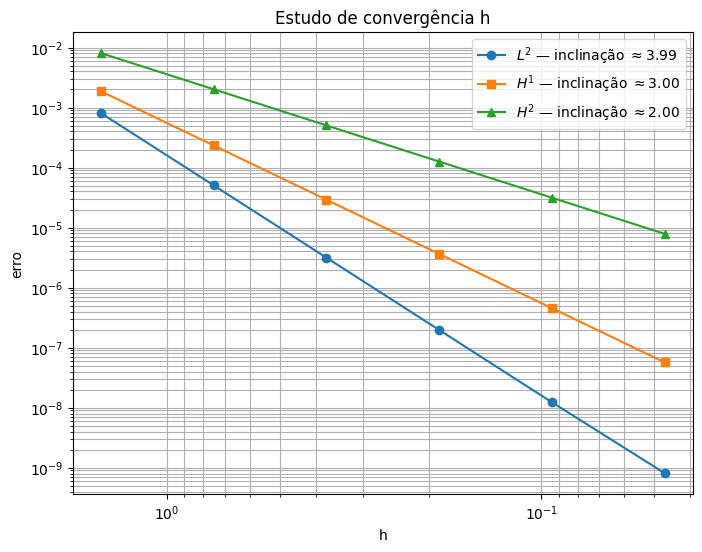

In [34]:
plt.figure(figsize=(8, 6))

plt.loglog(
    tabela_convergencia["h"],
    tabela_convergencia["erro_L2"],
    "o-",
    label=rf"$L^2$ — inclinação $\approx {coef_l2[0]:.2f}$",
)

plt.loglog(
    tabela_convergencia["h"],
    tabela_convergencia["erro_H1"],
    "s-",
    label=rf"$H^1$ — inclinação $\approx {coef_h1[0]:.2f}$",
)

plt.loglog(
    tabela_convergencia["h"],
    tabela_convergencia["erro_H2"],
    "^-",
    label=rf"$H^2$ — inclinação $\approx {coef_h2[0]:.2f}$",
)

plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("erro")
plt.title("Estudo de convergência h")
plt.grid(True, which="both")
plt.legend()
plt.show()


## Conclusão

Para elementos cúbicos de Hermite, esperamos as taxas

$$
\|u-u_h\|_{L^2(\Omega)}=O(h^4),
$$

$$
|u-u_h|_{H^1(\Omega)}=O(h^3),
$$

$$
|u-u_h|_{H^2(\Omega)}=O(h^2).
$$

Assim, no gráfico log-log, esperamos inclinações próximas de $4$, $3$ e $2$, respectivamente.

Como a solução analítica é um polinômio de grau $4$ e os elementos de Hermite são cúbicos por elemento, a solução aproximada não é exatamente igual à solução analítica. Portanto, os erros não são nulos, mas as taxas experimentais coincidem com as taxas teóricas esperadas.
